This notebook contains small calculations in preperation for modeling or for writing my thesis.

# Diffusivity Criteria

In [1]:
L = 55000
dt = 900
z = 1

A_h_max = L**2 / (4*dt)
A_v_max = z**2 / (4*dt)
print("Maximum horizontal diffusivity for stability: ", A_h_max)
print("Maximum vertical diffusivity for stability: ", A_v_max)

ratio = 0.1

print(" horizontal diffusivity for stability (10% of max): ", ratio * A_h_max)
print(" vertical diffusivity for stability (10% of max): ", ratio * A_v_max)

Maximum horizontal diffusivity for stability:  840277.7777777778
Maximum vertical diffusivity for stability:  0.0002777777777777778
 horizontal diffusivity for stability (10% of max):  84027.77777777778
 vertical diffusivity for stability (10% of max):  2.777777777777778e-05


# Freezing Temperature Properties

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gsw

In [3]:
# standard ocean
p_SO = 0 # standard ocean sea pressure (dbar)
T_SO = 0 # (celcius)
SA_SO = 35.16504 # (g/kg)

In [4]:
tf_fresh = gsw.t_freezing(SA=0, p=0, saturation_fraction=0)
tf_fresh_o2 = gsw.t_freezing(SA=0, p=0, saturation_fraction=1)

print("Freshwater Freezing Temperature: ", tf_fresh)
print("Freshwater O2 saturated: ", tf_fresh_o2)

Freshwater Freezing Temperature:  0.00251926654413357
Freshwater O2 saturated:  0.00011926654412432744


## Freezin Point as a function of \<variable>

### Salinity Dependence

Text(0.5, 1.0, 'Salinity Dependence of Surface Freezing Temperature')

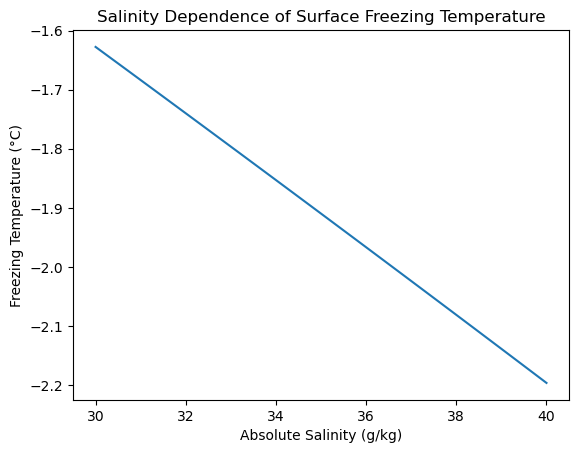

In [5]:
SA_min = 30 # g/kg
SA_max = 40 # g/kg
steps = 20
SAs = np.linspace(SA_min, SA_max, steps)

tf_sal = gsw.t_freezing(SA=SAs, p=0, saturation_fraction=0)

plt.plot(SAs, tf_sal)
plt.xlabel("Absolute Salinity (g/kg)")
plt.ylabel("Freezing Temperature (°C)")
plt.title("Salinity Dependence of Surface Freezing Temperature")



### Pressure Dependence

Total Difference:  0.7641918603728302


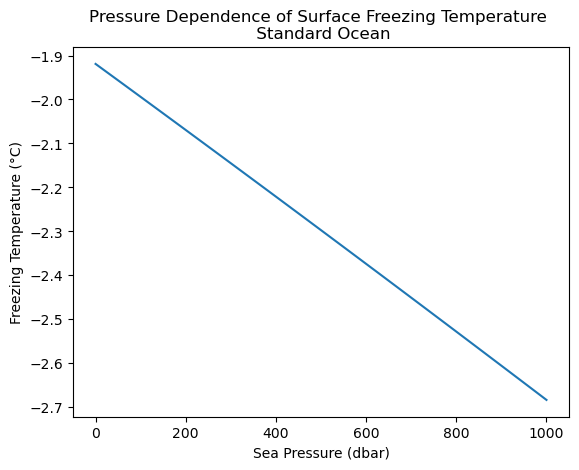

In [6]:
p_min = 0 
p_max = 1000
steps = 50

ps = np.linspace(p_min,p_max,steps)

tf_p = gsw.t_freezing(SA=SA_SO, p=ps, saturation_fraction=0)

plt.plot(ps, tf_p)
plt.xlabel("Sea Pressure (dbar)")
plt.ylabel("Freezing Temperature (°C)")
plt.title("Pressure Dependence of Surface Freezing Temperature \n Standard Ocean")
print("Total Difference: ", np.max(tf_p)-np.min(tf_p))


In [13]:
# first derivative by pressure

p_min = 0 
p_max = 300
steps = 50

ps = np.linspace(p_min,p_max,steps)
tf_deriv_p = gsw.t_freezing_first_derivatives(SA_SO, ps, 0)[1] # (K/Pa)

print(f"{np.max(tf_deriv_p)*1e4*1e3:.3f} mK/dbar")
print(np.min(tf_deriv_p)*1e4, "K/dbar")

-0.748 mK/dbar
-0.0007578441682492276 K/dbar


### Salinity & Pressure dependency

### Oxygen Dependence

0.0017100000001408766


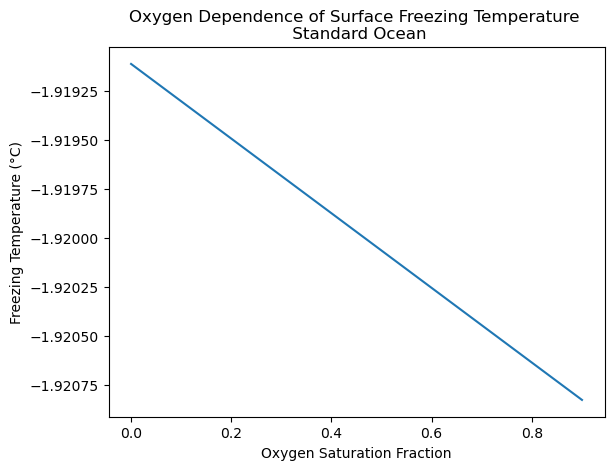

In [39]:
O2s = np.arange(0,1,0.1)

tf_O2 = gsw.t_freezing(SA=SA_SO, p=p_SO, saturation_fraction=O2s)

plt.plot(O2s, tf_O2)
plt.xlabel("Oxygen Saturation Fraction")
plt.ylabel("Freezing Temperature (°C)")
plt.title("Oxygen Dependence of Surface Freezing Temperature \n Standard Ocean")

print(np.max(tf_O2) - np.min(tf_O2))

## Freezing Point Derivatives

In [41]:
gsw.t_freezing_first_derivatives(SAs, p_SO, 0)

(array([-0.05924647, -0.0541763 , -0.05349249, -0.05330971, -0.05332892,
        -0.05345102, -0.05363287, -0.05385299, -0.05409989, -0.05436714,
        -0.05465113, -0.05494982, -0.05526211, -0.05558748, -0.05592572,
        -0.05627684, -0.05664093, -0.05701814, -0.05740862, -0.05781253]),
 array([-7.42934601e-08, -7.43028471e-08, -7.43180493e-08, -7.43364859e-08,
        -7.43574726e-08, -7.43807329e-08, -7.44061584e-08, -7.44337264e-08,
        -7.44634626e-08, -7.44954227e-08, -7.45296808e-08, -7.45663235e-08,
        -7.46054454e-08, -7.46471462e-08, -7.46915293e-08, -7.47386999e-08,
        -7.47887644e-08, -7.48418294e-08, -7.48980016e-08, -7.49573872e-08]))

In [42]:
gsw.t_freezing_first_derivatives(SA_SO, ps, 0)

(array([-0.05690488, -0.05690998, -0.05691508, -0.05692019, -0.0569253 ,
        -0.05693041, -0.05693553, -0.05694064, -0.05694576, -0.05695088]),
 array([-7.48257707e-08, -7.48898188e-08, -7.49538469e-08, -7.50178550e-08,
        -7.50818432e-08, -7.51458115e-08, -7.52097600e-08, -7.52736888e-08,
        -7.53375979e-08, -7.54014874e-08]))